<div align="center" markdown="1">

<span style="font-size: 36px; font-weight: bold;">
Detecting Drug Interactions with Machine Learning
</span>

<br><br>

**Luca Giobbi**  

<br>

**Supervisor**
<br>
Dr. Ekaterina Krymova
<br>

**Co-Supervisor**
<br>
Dr. Paraskevi Nousi | Dr. Maxim Samarin

<br>

DAS in Data Science  
ETH Zurich  

<br><br>

May 2026

</div>

In [2]:
import os
import warnings
import logging

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import precision_recall_curve, roc_curve

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import LossType
from report_utils import (
    plot_experiment_results,
    render_interactive_visualization,
    get_base_config,
    get_feature_experiment_config,
    compute_node_metrics,
    compile_embeddings,
    plot_pharma_class_error_rates,
    render_model_architecture,
    display_training_set_configurations,
)

In [3]:
warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.WARNING, format="%(asctime)s - %(levelname)s - %(message)s")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_style("whitegrid")
sns.set_context("talk")
os.environ.update({k: "1" for k in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]})

# Abstract

Drug-drug interactions (DDIs) are a major source of preventable adverse drug reactions in polypharmacy settings, yet exhaustive experimental screening remains costly and incomplete. This report studies DDI prediction as a link prediction problem on a harmonized pharmacological graph built by integrating the ChCh-Miner interaction network with clinically curated controls from CRESCENDDI. We evaluate a Graph Convolutional Network (GCN) that combines graph topology with semantic node attributes derived from DrugBank textual descriptions embedded using OpenAI's `text-embedding-ada-002`, and we compare this setting against a non-informative feature baseline.

Semantic enrichment of node features emerges as the key driver of improved predictive performance. In particular, the inclusion of clinically validated negative controls points toward further gains when such high-quality signals are more fully integrated into the dataset. Overall, the findings support LLM-enhanced graph learning as a practical and promising direction for computational pharmacovigilance and drug safety screening.

# 1 Introduction

Drug-drug interactions (DDIs) occur when the intended effect of one drug is modified by the co-administration of another. With the increasing prevalence of polypharmacy—especially among elderly populations managing multiple prescriptions—DDIs have become a significant challenge in clinical pharmacology. These interactions can alter absorption, distribution, metabolism, and excretion (pharmacokinetics) or modify tissue responsiveness (pharmacodynamics), frequently resulting in unexpected Adverse Drug Reactions (ADRs). Consequently, DDIs are a major driver of elevated healthcare costs, emergency room visits, and prolonged hospitalizations [[qiu2022_ddi]](#qiu2022_ddi).

Traditionally, identifying DDIs relied heavily on *in vivo* and *in vitro* laboratory research or premarketing clinical trials. However, these conventional approaches are expensive, time-consuming, and constrained by small sample sizes and brief exposure periods. Consequently, many interactions and critical safety issues often go unnoticed until post-marketing surveillance and wider population exposure. To overcome these limitations, the scientific community has increasingly turned to computational methods. By representing known DDIs accumulated in large biomedical databases, machine learning models can efficiently predict unobserved interactions, serving as highly scalable early-warning systems in pharmacovigilance [[qiu2022_ddi]](#qiu2022_ddi), [[zhao2024_ddi]](#zhao2024_ddi).

This report evaluates a machine learning approach for detecting clinically relevant drug–drug interactions by framing the task as link prediction on a unified knowledge graph. The central contribution lies in enriching the graph with semantic pharmacological information: dense embeddings derived from clinical drug descriptions using a Large Language Model serve as node features, allowing the model to move beyond purely structural signals. These features are processed through a Graph Convolutional Network, enabling the integration of relational and semantic context. Particular attention is given to handling class imbalance during training, ensuring robust learning. Overall, the work focuses on how semantic enrichment strengthens predictive performance and supports more meaningful therapeutic insights.

# 2 Materials and Methods

This section details the datasets used for the empirical evaluation, how the interaction graph was harmonized, and outlines the machine learning architecture employed for the link prediction task.

## 2.1 Dataset

We used a combination of a large-scale interaction network (ChCh-Miner) and a clinically validated reference set (CRESCENDDI) to construct a unified and reliable benchmark for drug–drug interaction prediction. To move beyond purely structural information, drug nodes were enriched with semantic features derived from clinical descriptions, as described below.

### 2.1.1 Graph
Our empirical evaluation relies on a robust and unified reference dataset that merges large-scale graph representations of drug knowledge with clinically validated interaction endpoints. To construct this benchmark, we integrated data from two primary resources: the ChCh-Miner network and the CRESCENDDI reference set.

**ChCh-Miner Network**  

The ChCh-Miner dataset is a curated drug–drug interaction (DDI) network of U.S. Food and Drug Administration (FDA)-approved drugs, originally derived from the DrugBank database and built using the MINER parser. It is represented as an undirected graph where nodes correspond to distinct pharmaceutical compounds and edges indicate documented interactions based on drug labels and scientific literature. The resulting graph is densely connected, comprising 1,514 nodes and 48,514 edges. The dataset exhibits strong local clustering, with a clustering coefficient of 0.30, and the largest strongly connected component encompasses nearly the entire network (1,510 nodes and 48,512 edges) [[chchminer]](#chchminer).

**CRESCENDDI Reference Set**  

The Clinically-relevant REference Set CENtered around Drug-Drug Interactions (CRESCENDDI) provides a gold-standard benchmark created specifically to evaluate signal detection algorithms in pharmacovigilance. The complete resource aggregates 10,286 positive controls and 4,544 negative controls, spanning 454 unique drug ingredients and 179 distinct adverse events standardly mapped to RxNorm and MedDRA terminologies.

To maximize clinical confidence, positive controls in CRESCENDDI were formulated through a strict intersection of three primary compendia: the British National Formulary (BNF), the French National Drug Safety Institute (ANSM) Thesaurus, and Micromedex. Following the normalization of pharmaceutical entities to RxNorm ingredient levels via OHDSI Usagi, the interaction descriptions underwent a blinding procedure where specific drug names were masked using generic tokens. A defining characteristic of this curation was the deliberate focus on empirical clinical manifestations (e.g., elevated risk of an adverse reaction), intentionally excluding entries that merely hypothesized pharmacological mechanisms.

Conversely, the negative control set was generated to rigorously minimize structural and reporting bias. Candidate negative pairs were constructed by randomly combining drugs and adverse events drawn from the existing control pool. Each candidate drug-drug-event triplet was then subjected to a custom automated PubMed query; only triplets yielding identically zero results in the scientific literature were retained. The final size of the negative control set was statistically calibrated to match the subset of positive controls demonstrating non-zero report frequencies in the FDA Adverse Event Reporting System (FAERS) [[crescenddi]](#crescenddi).

**Data Integration and Harmonization**  

To assemble the target graph for our predictive model, we extracted the intersection of the ChCh-Miner graph and the clinically validated CRESCENDDI reference set. This required mapping drug identifiers into a shared representation space using a cascading, case-insensitive matching strategy, first via standardized drug concept names and then via fallback matching on original drug names.

From 14,830 initial paired assertions, 414 edges were removed due to unresolved mappings to DrugBank identifiers. Since drug interactions are symmetric, all pairs were canonicalized by sorting identifiers and eliminating duplicates, reducing redundancy from 14,416 intermediate edges by 5,625 cases.

Finally, we enforced strict consistency between datasets by removing CRESCENDDI negative controls that overlapped with confirmed positive interactions in ChCh-Miner. The resulting harmonized graph contains 8,791 unique drug–drug interactions.


### 2.1.2 Node Features and Embeddings

To enrich the structural interaction data with robust semantic, biochemical, and clinical context, we incorporate dense text embeddings as initial node features ($\mathbf{x}_v$) within our graph model. 

Brief, domain-specific textual descriptions for each pharmaceutical compound were originally sourced from the DrugBank database [[drugbank]](#drugbank). For our empirical pipeline, we directly utilized the curated textual preparations publicly provided by the DDI-LLM framework [[ddillm]](#ddillm). 

These variable-length qualitative descriptions were computationally mapped into a continuous, fixed-dimensional real coordinate space using OpenAI's `text-embedding-ada-002` model [[openai_ada]](#openai_ada). Such text embeddings explicitly encode semantic relationships geometrically, guaranteeing that biologically or chemically related drugs occupy proximate regions within the embedding space. This structure subsequently enables nearest-neighbor retrieval and quantitative comparisons typically evaluated via cosine similarity. Off-the-shelf embeddings constructed by large language models have been demonstrably shown to capture transferable semantic structure highly beneficial as functional priors for downstream graph learning tasks [[text_embeddings]](#text_embeddings). 

These semantic vectors are used as initial node features in the Graph Convolutional Network, replacing a naive baseline of constant, non-informative inputs (all-one vectors). This allows the model to operate directly on semantically informed representations rather than purely uniform feature initializations.



## 2.2 Model Architecture

We formulate drug-drug interaction (DDI) prediction as a link prediction task on an undirected, homogeneous graph $\mathcal{G} = (\mathcal{V}, \mathcal{E})$, where vertices $v \in \mathcal{V}$ represent individual drugs and edges $e_{u,v} \in \mathcal{E}$ denote validated interactions. Each node $v$ is initialized with a feature vector $\mathbf{x}_v \in \mathbb{R}^d$, representing either dense pre-trained language model embeddings extracted from drug descriptions or a constant baseline vector.

Our architecture employs an encoder-decoder framework. The encoder utilizes a Graph Convolutional Network (GCN) to project node features into a rich, topology-aware latent space, while the decoder computes the pairwise probability of an edge existing between any two nodes.

### 2.2.1 Graph Convolutional Encoder
The encoder learns structural node representations by recursively aggregating features from local neighborhoods. We stack three graph convolutional layers. The propagation rule for the $l$-th layer is defined as:

$$
\mathbf{H}^{(l+1)} = \text{ReLU} \left( \tilde{\mathbf{D}}^{-\frac{1}{2}} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-\frac{1}{2}} \mathbf{H}^{(l)} \mathbf{W}^{(l)} \right)
$$

where:
- $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$ is the adjacency matrix with added self-loops.
- $\tilde{\mathbf{D}}$ is the corresponding degree matrix defined by $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$.
- $\mathbf{H}^{(l)}$ is the matrix of hidden node representations at layer $l$, with $\mathbf{H}^{(0)} = \mathbf{X}$.
- $\mathbf{W}^{(l)}$ is the layer-specific trainable weight matrix.

**Network Configuration:** 
The network consists of three layers. The first layer projects the initial $d$-dimensional input features into a 256-dimensional hidden space. The second and third layers maintain this 256-dimensional representation. To introduce non-linearity and combat severe overfitting, we apply a Rectified Linear Unit (ReLU) and Dropout regularization (with rate $p=0.3$) after the first and second convolutional operations. The final layer emits the encoded vertex embeddings $\mathbf{z}_v \in \mathbb{R}^{256}$ without additional non-linear activations.

### 2.2.2 Pairwise Dot-Product Decoder
To predict the absence or presence of an interaction between two drugs $u$ and $v$, the decoder acts directly on the learned latent representations $\mathbf{z}_u$ and $\mathbf{z}_v$. We employ a symmetric inner-product (dot-product) decoder to model the structural similarity in the embedded space:

$$
\hat{s}_{u,v} = \mathbf{z}_u^\top \mathbf{z}_v
$$

The scalar output $\hat{s}_{u,v}$ serves as the unnormalized predicted logit representing the log-odds of an interaction edge. During inference, these logits are mapped to valid probabilities via the standard logistic sigmoid function $\hat{y}_{u,v} = \sigma(\hat{s}_{u,v})$.

### 2.2.3 Optimization and Training Dynamics
The model is trained entirely end-to-end to correctly classify true drug-drug interactions (positive edges) against non-interacting pairs (negative edges).

**Loss Function:** 
We explicitly counteract the severe class imbalance inherent to drug interaction graphs using a weighted binary cross-entropy (BCE) loss. Let $p=\sigma(z)$ be the model probability (sigmoid of the logit $z$), $y\in\{0,1\}$ the true label, and $N_{pos},N_{neg}$ the counts of positive and negative examples used for training. We define a positive‑class scaling factor:

$$
\alpha_{pos} = \mathrm{pos\_loss\_multiplier} \cdot \frac{N_{neg}}{N_{pos}},
$$

and set the negative weight to $\alpha_{neg}=1$. The per‑example weighted binary cross‑entropy is computed as:

$$
\mathcal{L}(p,y) = -\alpha_{pos}\,y\,\log p - \alpha_{neg}\,(1-y)\,\log(1-p).
$$

In PyTorch, this is computationally achieved by providing a `pos_weight` parameter to `BCEWithLogitsLoss` (equal to $\alpha_{pos}$ above), explicitly scaling the positive class's contribution based on the empirical ratio and optimal scalar adjustment.

*Note on Focal Loss:* The binary focal loss modifies cross‑entropy with a focusing term, defined as $\mathrm{FL}(p_t) = -\alpha\,(1-p_t)^{\gamma}\,\log(p_t)$, where $\gamma\ge 0$ focuses training on difficult examples. During hyperparameter search, we observed the optimal focal parameter gracefully collapsed to $\gamma\approx 0$ (reducing the formula back to standard weighted BCE). Hence, focal loss provided no empirical advantage over standard weighted BCE for this graph topology.

**Training Regimen:** 
Stochastic gradient descent is performed via the Adam optimizer using an initial learning rate decay scheduled via a MultiplicativeLR modifier. To enforce generalization and prevent topological memorization, we monitor the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) on a held-out validation set at each epoch. The training loop employs an early stopping mechanism with a configured patience threshold on the validation ROC-AUC to isolate and retain the optimal model parameter state of the model parameters.

In [3]:
render_model_architecture()

# 3 Experiments and Results

In this section we assess the performance of our Graph Neural Network. We evaluate the impact of different loss configurations for handling class imbalance, and compare the effectiveness of semantically enriched language model embeddings against a constant feature baseline. Moreover, we provide an exploratory analysis for our final model.

## 3.1 Experiments on Loss Functions and Labels

For model tuning, we conducted a systematic evaluation of how the choice of loss function interacts with different strategies for constructing negative training examples. In particular, we investigated how non-interacting pairs are defined during training and how these choices influence learning under strong class imbalance.

We consider three strategies for generating negative examples. First, sampled negatives are drawn uniformly from unlabeled drug pairs and treated as negative instances. This approach reflects a standard assumption in sparse graphs—that most unobserved edges are non-interactions—while acknowledging the risk that some true positives may be included among these samples. Second, observed (validated) negatives rely exclusively on the clinically confirmed non-interactions provided by the CRESCENDDI dataset. Because this yields a much smaller negative set, class imbalance is addressed through loss weighting rather than expanding the sample size. Third, upsampled negatives replicate validated negative examples via sampling with replacement until the number of negatives matches the number of positives, enforcing a balanced training distribution at the cost of altering the underlying data proportions.


**Experimental Design**

To identify an optimal model configuration, we systematically evaluate six distinct training setups derived from combinations of loss formulation and negative sampling strategy. Across all experiments, OpenAI's ADA description embeddings are used as fixed initial node features.

The design space is defined by three binary factors. First, we compare a standard binary cross-entropy loss (BCEWithLogitsLoss) against a weighted variant that applies a reduced positive-class scaling (pos-loss multiplier of 0.5) to account for class imbalance. Second, we vary whether negative examples are upsampled to match the number of positives or left in their original empirical proportion. Third, we distinguish between using randomly sampled negatives from the unlabeled space versus restricting training to validated negatives only, as controlled by the use_only_sampled_negatives_in_train flag.

Combining these choices yields six training configurations, covering all combinations of loss type, negative balancing strategy, and negative source selection. This setup allows us to isolate the effect of each component under consistent feature representations.

### 3.1.1 Optimizing individual losses

In [4]:
settings = [
    {
        "loss_type": LossType.BCEWithLogitsLoss,
        "pos_loss_multiplier": 1,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.BCEWithLogitsLoss,
        "pos_loss_multiplier": 1,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": True,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": True,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": False,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": False,
        "use_only_sampled_negatives_in_train": True,
    },
]

In [5]:
results_list = []
for i, setting in enumerate(settings):
    config = get_base_config()
    config.run.loss_type = setting["loss_type"]
    config.run.pos_loss_multiplier = setting["pos_loss_multiplier"]
    config.run.upsample_negative_labels = setting.get("upsample_negative_labels", False)
    config.run.use_only_sampled_negatives_in_train = setting.get("use_only_sampled_negatives_in_train", False)

    name = f"{setting['loss_type'].name}|mult={setting['pos_loss_multiplier']}|ups={setting.get('upsample_negative_labels', False)}|only_sampled={setting.get('use_only_sampled_negatives_in_train', False)}|reps={config.training.repetitions}"
    print(f"=== Running [{i + 1}/{len(settings)}]: {name} ===")

    run = main(config)
    y_true, y_scores = np.asarray(run["label"]), np.asarray(run["test_scores"])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    results_list.append(
        {"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr}
    )

settings_results = results_list

=== Running [1/6]: BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=5 ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6913
PR_AUC: 0.9655
std ROC_AUC: 0.0027
std PR_AUC: 0.0005
repetitions: 5
-------------------------------
=== Running [2/6]: BCEWithLogitsLoss|mult=1|ups=True|only_sampled=True|reps=5 ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6899
PR_AUC: 0.9651
std ROC_AUC: 0.0043
std PR_AUC: 0.0007
repetitions: 5
-------------------------------
=== Running [3/6]: WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=False|reps=5 ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7371
PR_AUC

In [6]:
_ = display_training_set_configurations(settings)

### Training Set Configurations

|    | Loss Function             |   Observed Positives in Train |   Observed Negatives in Train |   Sampled Negatives in Train |   Weight Factor Negative Loss |
|:---|:--------------------------|------------------------------:|------------------------------:|-----------------------------:|------------------------------:|
| S1 | BCEWithLogitsLoss         |                         30066 |                          2272 |                        27794 |                        1      |
| S2 | BCEWithLogitsLoss         |                         30066 |                             0 |                        30066 |                        1      |
| S3 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                        27794 |                        2      |
| S4 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                        30066 |                        2      |
| S5 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                            0 |                       26.4665 |
| S6 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                         2272 |                       26.4665 |

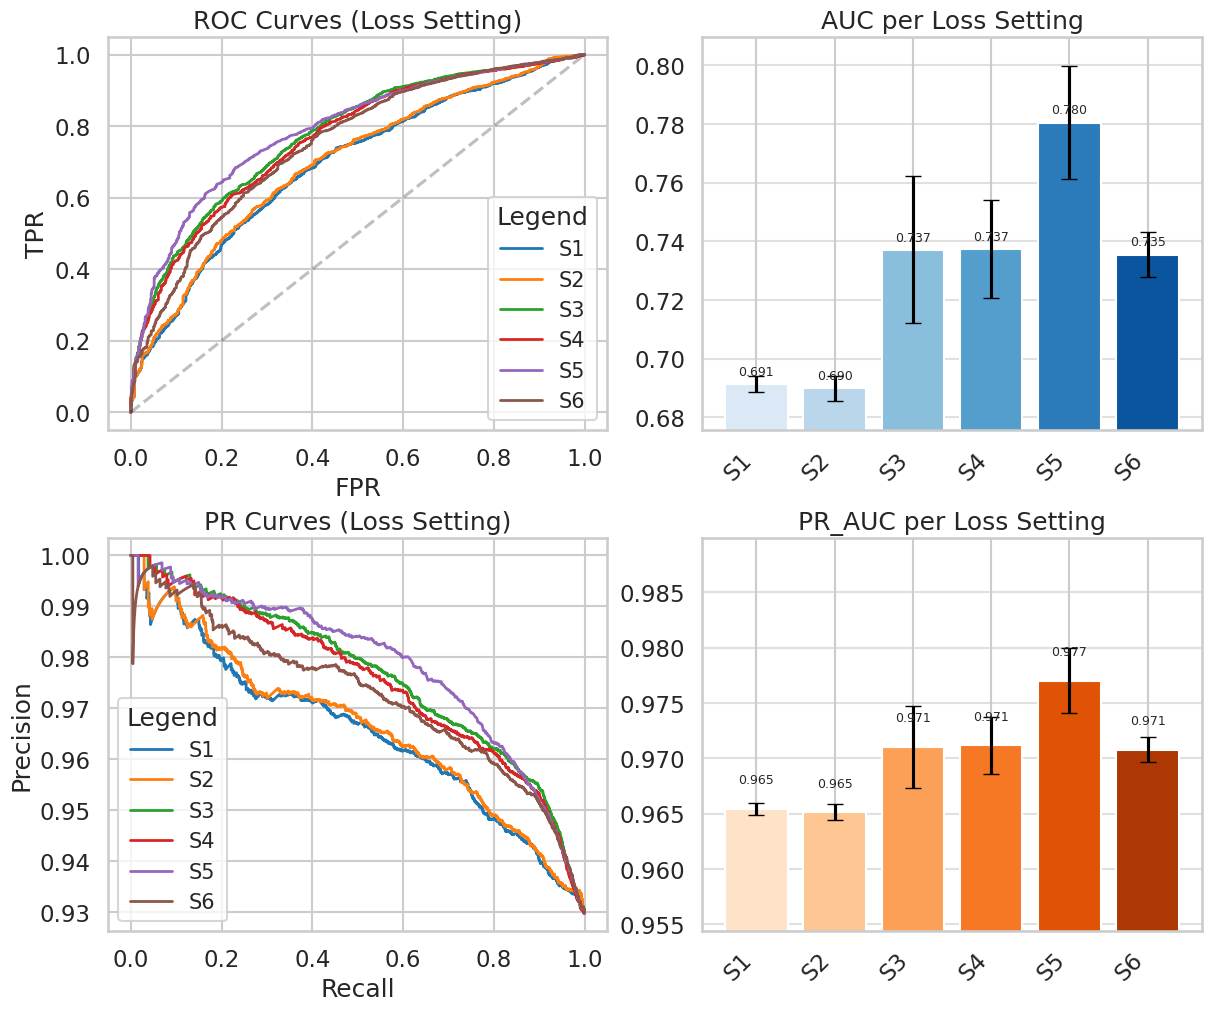

##### Summary of Metrics (Loss Setting)

| short name   |   AUC_mean |    AUC_std |   PR_AUC_mean |   PR_AUC_std |
|:-------------|-----------:|-----------:|--------------:|-------------:|
| S1           |   0.69127  | 0.00268133 |      0.965459 |  0.000530449 |
| S2           |   0.689866 | 0.00426031 |      0.965148 |  0.000745784 |
| S3           |   0.737131 | 0.0250667  |      0.971048 |  0.00369073  |
| S4           |   0.737404 | 0.0167211  |      0.971192 |  0.00255921  |
| S5           |   0.780446 | 0.0192876  |      0.977024 |  0.00292122  |
| S6           |   0.735478 | 0.00766284 |      0.97078  |  0.00110619  |

In [7]:
# Generate plots and metrics output for the Loss Settings
plot_experiment_results(settings_results, title_suffix="Loss Setting", filename="report_grid.png")

### 3.1.2 Summary of Empirical Findings

Across all evaluated configurations, applying a reduced positive-class weighting with positive loss multiplier scaled down to $\approx 0.5$ relative to the class ratio consistently outperformed the standard unweighted binary cross-entropy loss. This indicates that explicitly correcting for class imbalance via loss reweighting is beneficial for stable training.

We further observe that the choice of negative examples has a strong impact on performance. Using clinically validated negatives from CRESCENDDI generally leads to better results than relying on uniformly sampled negatives from the unlabeled interaction space, particularly when combined with loss weighting to account for the smaller negative set. This suggests that curated non-interactions provide a higher-quality learning signal.

In contrast, artificially upsampling negatives to enforce class balance does not improve performance and can even reduce validation quality in some settings. Overall, the most effective configuration preserves the empirically observed class distribution and addresses imbalance through weighted loss rather than data resampling.

## 3.2 Evaluating Node Feature Representations

Having established the optimal loss configuration from the above experiments, we now systematically evaluate the impact of input node features. We benchmark a baseline, non-informative feature strategy (an initial node feature vector uniformly initialized to ones, denoted as `__ONES__`) against dense, domain-focused LLM-derived features generated via OpenAI's ADA model (`DESC_GPT`).

### 3.2.1 LLM Embeddings vs. Baseline Initialization

Throughout these downstream experimental evaluations, all auxiliary components of the learning pipeline—including the training/test splits, optimal weighted BCE loss configuration, network architectural sizes, and all associated training hyperparameters—were held strictly constant. By keeping the underlying topological processing and optimization framework frozen, any resulting variance precisely isolates the true classification capability gain, allowing improvements in validation metrics to be explicitly attributed to the underlying semantic knowledge captured by the embedded structural representations.

In [8]:
feature_settings = [
    {
        "feature": "__ONES__",
    },
    {
        "feature": "DESC_GPT",
    },
]

In [9]:
feature_results = []
for i, setting in enumerate(feature_settings):
    feature = setting.get("feature")
    # Use the isolated config definition for feature evaluation
    config_feature = get_feature_experiment_config()
    config_feature.graph.feature = feature

    name = f"Feature|{feature}"
    print(f"=== Running [{i + 1}/{len(feature_settings)}]: {name} ===")

    run = main(config_feature)
    y_true, y_scores = np.asarray(run["label"]), np.asarray(run["test_scores"])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    feature_results.append(
        {"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr}
    )

=== Running [1/2]: Feature|__ONES__ ===
======== __ONES__ ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE __ONES__ -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6639
PR_AUC: 0.9617
std ROC_AUC: 0.0025
std PR_AUC: 0.0004
repetitions: 5
-------------------------------
=== Running [2/2]: Feature|DESC_GPT ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7804
PR_AUC: 0.9770
std ROC_AUC: 0.0193
std PR_AUC: 0.0029
repetitions: 5
-------------------------------


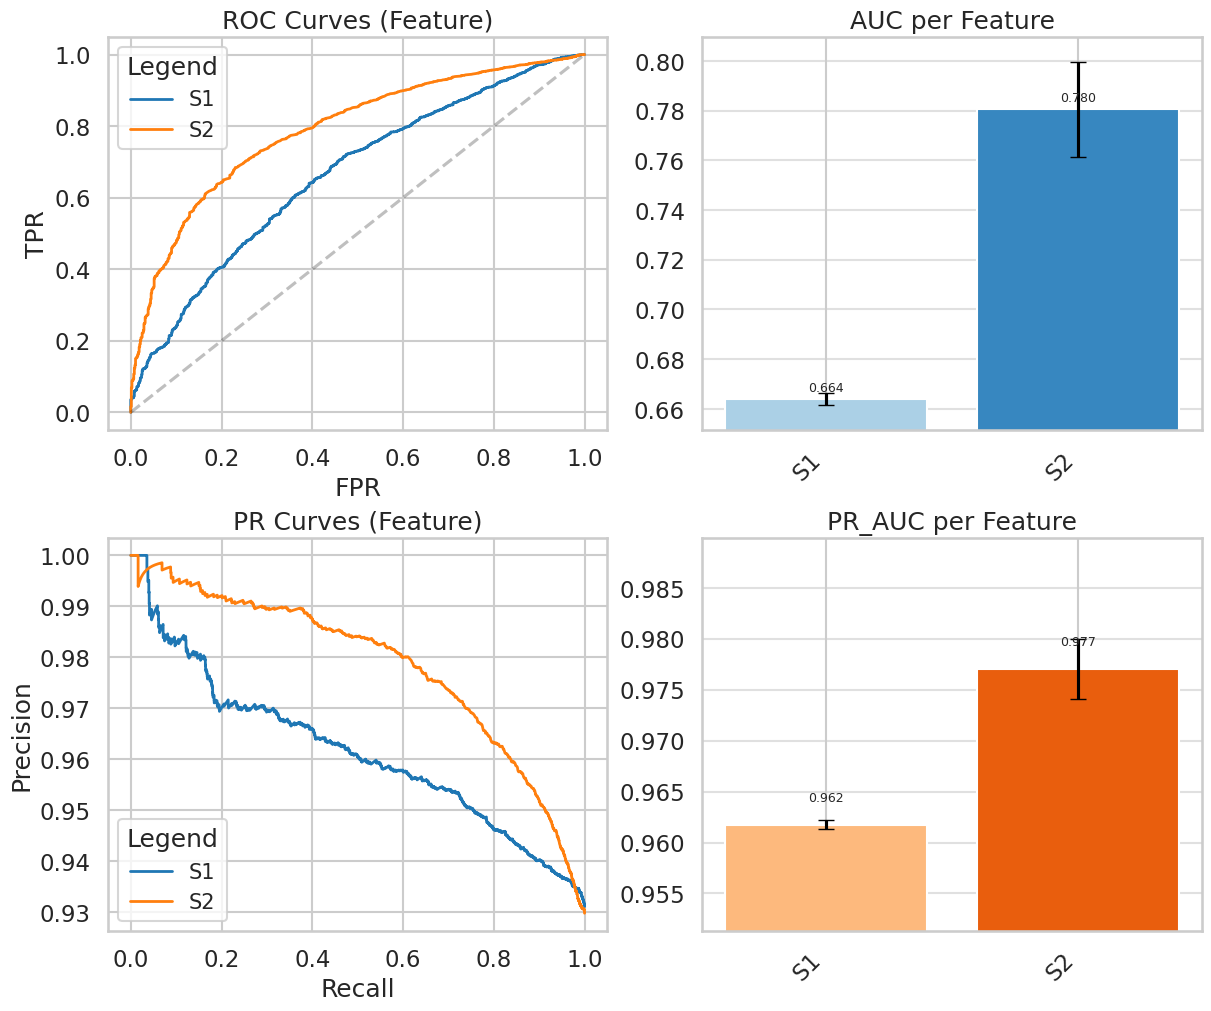

##### Summary of Metrics (Feature)

| short name   |   AUC_mean |    AUC_std |   PR_AUC_mean |   PR_AUC_std |
|:-------------|-----------:|-----------:|--------------:|-------------:|
| S1           |   0.663902 | 0.00251414 |      0.961745 |  0.000439017 |
| S2           |   0.780446 | 0.0192876  |      0.977024 |  0.00292121  |

In [10]:
# Generate plots and metrics output for the Embeddings Settings
plot_experiment_results(feature_results, title_suffix="Feature", filename="report_grid_features.png")

Across both evaluation metrics, we observe a clear and consistent improvement in predictive performance when incorporating LLM-derived description embeddings as node features.

In terms of the area under the receiver operating characteristic curve (ROC-AUC), the model shows a substantial gain, indicating a markedly improved ability to distinguish between interacting (positive) and non-interacting (negative) drug pairs across all decision thresholds. This reflects a stronger overall ranking quality of predicted interactions.

A similarly strong improvement is observed in the precision-recall AUC (PR-AUC), which is particularly relevant in the presence of class imbalance. The increase in PR-AUC indicates that the model achieves a better balance between precision and recall when identifying drug–drug interactions, meaning it is more effective at maintaining high sensitivity to true interactions while reducing false positives. Overall, these results suggest that the semantic information encoded in the embeddings provides a meaningful inductive signal that enhances the model’s ability to learn discriminative representations of drug relationships.

## 3.3 Final Model Evaluation

In this section, we evaluate the model in its best-performing configuration, using GPT-3–derived embeddings of drug descriptions as node features together with a weighted binary cross-entropy loss and without upsampling of negative examples. For comparability across experiments and to enable a more interpretable confusion matrix, we calibrate the decision threshold such that the predicted positive and negative classes are balanced.

In this optimal setup, the inclusion of semantic description embeddings emerges as a key driver of performance improvements over the constant-feature baseline. The results indicate that providing the model with semantically informed node representations substantially strengthens its ability to learn meaningful interaction patterns in the data.

To better understand the nature of this improvement, we complement the aggregate metrics with a set of exploratory analyses presented in the following sections. While these results consistently point toward the benefit of semantic enrichment, further ablation studies are necessary to disentangle the individual contributions of the desciptions and to fully assess the robustness and statistical significance of the observed gains.

In [6]:
# Run the model using the analysis config
config_analysis = get_feature_experiment_config()
config_analysis.graph.feature = "DESC_GPT"
config_analysis.training.repetitions = 1

run = main(config_analysis)

# Unpack run results
test_data, test_scores, data, model = run["test_data"], run["test_scores"], run["data"], run["model"]
reversed_node_id_map = {v: k for k, v in run["node_id_map"].items()}

======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


In [8]:
# Compute threshold and mapped predictions, and aggregate classification counts across all connected edges per source
threshold, node_info_trained = compute_node_metrics(test_data, test_scores, reversed_node_id_map)

# Extract spatial and feature embeddings, resolve ATC classes and compile into a single dataframe
embedding = compile_embeddings(model, data, reversed_node_id_map, node_info_trained)


print(f"Threshold: {threshold:.4f} | Negatives: {node_info_trained['FN'].sum() + node_info_trained['TN'].sum()}")
# display(node_info_trained.head())
display(embedding.head(3))

Threshold: 0.5001 | Negatives: 10760


,TSNE-1_input,TSNE-2_input,TSNE-1_latent,TSNE-2_latent,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,drug_name,atc_match,atc_class_lvl_1,perc_missclassified,balanced_error_rate,edge_count,perc_neg_gt
DB00005,25.9436,-42.3272,-31.7284,27.8253,Etanercept,Dimeric fusion protein consisting of the extra...,Dimeric fusion protein consisting of the extra...,2,3,0,etanercept,Etanercept,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,0.0000,0.0000,3.0000,0.0000
DB00006,0.4283,-38.5689,15.2369,42.5225,Bivalirudin,Bivalirudin is a synthetic 20 residue peptide ...,<DRUG> is a synthetic 20 residue peptide (<DRU...,2,4,1,bivalirudin,Bivalirudin,BLOOD AND BLOOD FORMING ORGAN DRUGS,100.0000,0.5000,6.0000,0.0000
DB00007,49.8260,46.2119,34.3318,-26.9522,Leuprolide,Leuprolide is a synthetic 9-residue peptide an...,<DRUG> is a synthetic 9-residue peptide analog...,1,4,2,leuprolide,NaN,NaN,27.5000,0.1375,40.0000,0.0000


### 3.3.1 Error Analysis by Anatomical Therapeutic Chemical (ATC) Class

To effectively analyze model error rates and categorize drug properties across broader therapeutic and chemical boundaries, we incorporate the Anatomical Therapeutic Chemical (ATC) classification system. Developed by the WHO, the ATC system hierarchically stratifies active pharmaceutical substances based on the specific organ or system upon which they act, as well as their therapeutic, pharmacological, and chemical properties. The classification comprises five discrete levels 

- 1st level: main anatomical/pharmacological group,
- 2nd level: main pharmacological/therapeutic subgroup,
- 3rd-4th levels: chemical/pharmacological/therapeutic subgroups,
- 5th level: precise chemical substance using International Nonproprietary Name,
  
as defined in [[who_atc]](#who_atc).
 
For the purpose of this analysis, ATC labels were integrated into the interaction graph via exact string matching on drug names. While most compounds could be successfully mapped, 176 out of 1,510 drugs could not be uniquely assigned an ATC class, and are therefore grouped under the category “Unknown” in the preceding analysis.

Using the mapped subset, we compute aggregated error statistics per ATC class on the test set, including the number of drugs per class as well as summary measures of misclassification such as the median, mean, standard deviation, and interquartile range. The resulting distributions are visualized in the accompanying boxplot, allowing comparison of model performance across therapeutic categories.

,class,n,median,IQR,mean,std
9,NERVOUS SYSTEM DRUGS,248,29.4093,38.3356,38.5599,32.9028
2,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,177,64.7059,66.6667,64.2071,34.2902
13,Unknown,176,90.2778,66.6667,67.2695,38.4224
0,ALIMENTARY TRACT AND METABOLISM DRUGS,163,82.7586,57.7381,68.8032,33.6697
5,CARDIOVASCULAR SYSTEM DRUGS,162,61.8056,63.9388,60.6399,31.5134
1,ANTIINFECTIVES FOR SYSTEMIC USE,152,88.8889,58.7500,71.8585,33.0236
11,SENSORY ORGAN DRUGS,115,71.4286,58.2011,64.3044,32.8076
10,RESPIRATORY SYSTEM DRUGS,104,21.5251,62.7493,36.5128,36.8971
6,DERMATOLOGICALS,90,66.6667,66.2162,64.7818,34.1525
7,GENITO URINARY SYSTEM AND SEX HORMONES,79,85.7143,57.7778,71.0995,31.8836


/home/giobbi/DDI_LLM_repo/DDI_with_ML/report/report_utils.py:195: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


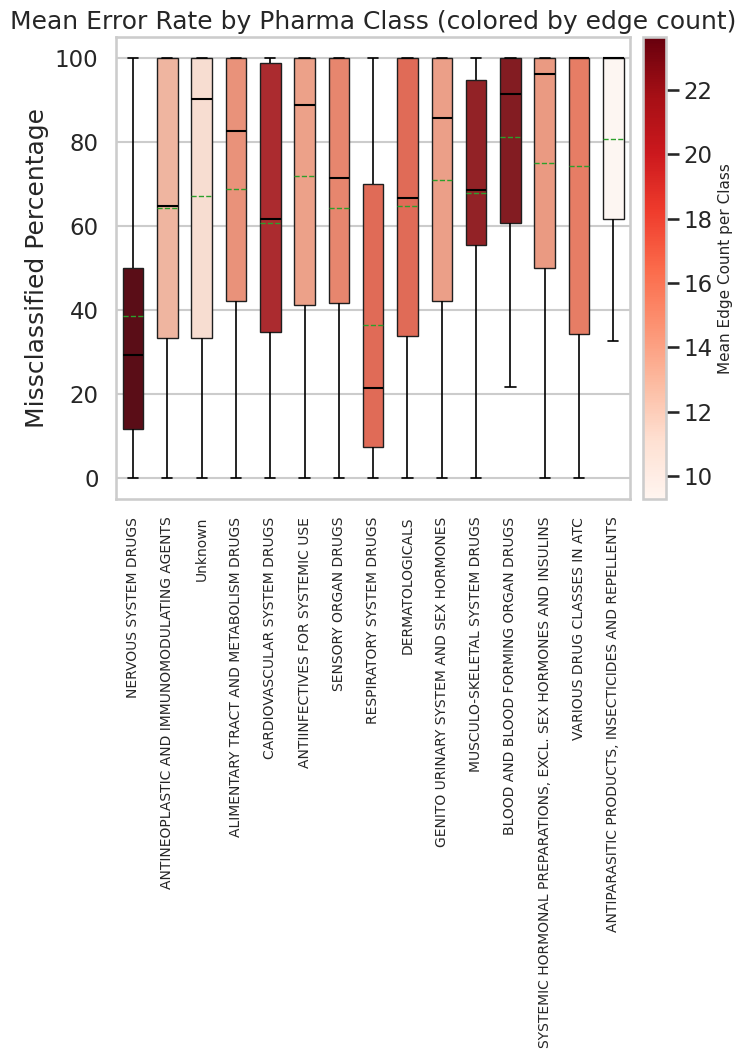

In [9]:
# Summarize error rates by Pharma Class and plot distribution using a Seaborn boxplot
plot_pharma_class_error_rates(embedding)

The per-class misclassification rates across ATC drug classifications reveal interesting performance variations among therapeutic categories. Our analysis presents the median (black), mean (green), and interquartile range of misclassification rates for each ATC class. The visualization shows that drugs targeting the nervous system and respiratory system exhibit notably lower misclassification rates compared to other therapeutic categories. This observation naturally raises the question of whether the lower error rates are driven by intrinsic properties of the drug classes themselves, or whether they reflect structural aspects of the dataset. In particular, differences in class size, interaction density, or the distribution of negative labels across ATC categories may all contribute to the observed variation in performance. 

These class-specific performance differences may reflect either intrinsic differences in drug predictability or structural biases in class distribution, motivating further controlled analysis.

### 3.3.2 Latent Space Representation Learning

To investigate what structural information is captured from drug descriptions and how it relates to improved predictive performance, we analyze the learned representations using a two-dimensional t-SNE projection of test-set embeddings. We compare two representation spaces: the original input space defined by GPT-3–derived drug description embeddings, and the latent space produced by the trained graph convolutional network after message passing on these features.

Across both spaces, we observe that clustering patterns are largely aligned with ATC drug class membership. This suggests that therapeutic classification encodes meaningful underlying chemical and biological structure, which is reflected in the representations learned by the model for interaction prediction.

#### Interactive Visualization

The interactive visualization enables detailed exploration of individual drugs and their predicted interactions. By selecting a drug of interest from the dropdown menu, users can examine all edges linking to that drug in the test set, with each edge color-coded according to its classification outcome (true positive, false positive, false negative, or true negative). The visualization further allows filtering by ATC class and edge type, facilitating targeted analysis of model performance across different therapeutic categories.

Each data point in the plot is accompanied by comprehensive metadata, including the drug name, DrugBank identifier, ATC classification, t-SNE coordinates, and the full description text used to generate the initial embeddings. This integrated view supports both qualitative inspection of individual cases and systematic exploration of systematic patterns in model predictions.

In [10]:
# ===== INTERACTIVE VISUALIZATION =====
render_interactive_visualization(embedding, test_data, test_scores, threshold, reversed_node_id_map)

# 4 Discussion

In this study, we investigated the combination of Graph Convolutional Networks (GCNs) with Large Language Model (LLM)–derived feature embeddings for the task of predicting drug–drug interactions (DDIs). By harmonizing the ChCh-Miner interaction network with the clinically validated CRESCENDDI reference set, we constructed a high-confidence benchmark graph for learning interaction patterns. A central component of this setup is the use of clinically curated negative controls, which provide a more reliable basis for distinguishing true interactions from non-interactions during training.

Across all experiments, we observe that enriching nodes with domain-specific textual descriptions encoded via OpenAI’s text-embedding-ada-002 leads to a substantial improvement in predictive performance. Relative to a non-informative baseline, this semantic enrichment increases ROC-AUC from 0.66 to 0.78 and PR-AUC from 0.96 to 0.98, demonstrating a consistently improved ability to separate interacting from non-interacting drug pairs.

A key factor behind the model’s stability is the careful design of the learning signal under strong class imbalance. We find that relying on clinically validated negatives from CRESCENDDI leads to better generalization than using uniformly sampled unlabeled pairs or artificially upsampling the minority class. In combination with this, a weighted Binary Cross-Entropy (BCE) loss—using a reduced positive loss multiplier of 0.5 relative to the empirical ratio—provides an effective mechanism to mitigate imbalance without distorting the underlying data distribution.

Beyond aggregate performance metrics, the learned representations reveal meaningful structural organization. t-SNE projections of the latent space show that drug embeddings cluster in accordance with Anatomical Therapeutic Chemical (ATC) classifications. This suggests that the model successfully integrates semantic information from unstructured drug descriptions with graph topology to recover biologically and therapeutically coherent structure, even without explicit supervision on ATC labels.

Despite strong overall results, the ATC-level error analysis highlights systematic variation in performance across therapeutic classes. Drugs targeting the nervous and respiratory systems, in particular, exhibit lower misclassification rates than other categories. It remains unclear whether this reflects inherent differences in the predictability of these drug classes or structural properties of the dataset, such as variations in class size, interaction density, or label distribution within ChCh-Miner. These observations underscore the need for further ablation studies to disentangle biological signal from dataset-induced bias and to better understand model behavior in different therapeutic regimes.

## 4.1 Future Work and Open Points

Several directions remain open to further validate and extend the proposed framework.

A first key limitation concerns the interpretability of the learned signal. While the model benefits from LLM-derived embeddings, it is not yet clear which aspects of these representations drive performance gains. As a next step, we therefore propose systematic ablation studies that replace semantic embeddings with simpler encodings, such as one-hot ATC class vectors. This would help disentangle whether the model primarily leverages broad therapeutic structure or whether it captures more fine-grained biochemical and pharmacological relationships encoded in the text. More generally, understanding which latent factors—such as pharmacokinetic properties, target affinities, or mechanistic descriptions—are most influential remains an open question.

Closely related to this is the question of evaluation robustness. While our current benchmark provides strong internal validation, future work should extend the evaluation to the Open Graph Benchmark ogbl-ddi dataset [[ogb]](#ogb). Unlike random split settings, this dataset introduces a protein-target-based separation between train and test drugs, forcing the model to generalize to unseen biological mechanisms rather than relying on similarity to known compounds. This makes it a more realistic and challenging testbed for drug–drug interaction prediction, with performance evaluated under a ranking-based metric (Hits@K) over a large set of candidate negatives [[guney2017]](#guney2017).

Furthermore, our results indicate that the use of CRESCENDDI negative controls contributes to improved model performance compared to alternative negative sampling strategies. Beyond providing binary labels for non-interactions, the CRESCENDDI dataset also includes confidence annotations for these negative controls. In future work, these confidence signals could be incorporated directly into the training objective to further refine the learning process and potentially improve predictive accuracy.

Finally, one straightforward extension concerns the embedding model itself. Our current approach relies on OpenAI’s text-embedding-ada-002 to encode drug descriptions into feature vectors. However, more recent embedding architectures, such as Gemini Embedding 2 [[gemini]](#gemini) or OpenAI’s text-embedding-3-large [[openai_v3]](#openai_v3), offer improved representational capacity. Updating the node feature generation to these newer models could refine the semantic structure of the input space, potentially leading to more informative latent representations and further gains in downstream predictive performance.

# 5 Conclusion

In conclusion, this study demonstrates the value of integrating modern natural language representations into graph-based models for drug–drug interaction (DDI) prediction. By augmenting a Graph Convolutional Network with dense semantic embeddings derived from LLM-encoded drug descriptions, we observe a clear improvement in predictive performance compared to non-informative feature baselines. In parallel, our experiments highlight the importance of a carefully designed learning setup: in particular, training on clinically validated negative examples combined with an appropriately scaled binary cross-entropy loss leads to stronger generalization than relying on uniformly sampled negatives.

Beyond aggregate performance, the model learns meaningful structure in the data, as reflected in ATC-aligned clustering in the latent space and consistent patterns in the error analysis. At the same time, remaining performance differences across therapeutic classes indicate that dataset composition and biological complexity may still influence model behavior.

Overall, the results support the combination of graph-based learning with semantic language representations as a promising direction for computational pharmacovigilance.

# References

**[qiu2022_ddi]** <span id="qiu2022_ddi">Qiu, Y., Zhang, Y., Deng, Y., Liu, S., and Zhang, W. (2022). "A Comprehensive Review of Computational Methods for Drug-Drug Interaction Detection." *IEEE/ACM Transactions on Computational Biology and Bioinformatics*, vol. 19, no. 4, pp. 1968-1985. [doi: 10.1109/TCBB.2021.3081268](https://ieeexplore.ieee.org/abstract/document/9435097).</span>  

**[zhao2024_ddi]** <span id="zhao2024_ddi">Zhao, Y., Yin, J., Zhang, L., Zhang, Y., and Chen, X. (2024). “Drug–drug interaction prediction: databases, web servers and computational models.” *Briefings in Bioinformatics*, vol. 25, no. 1, bbad445. [doi: 10.1093/bib/bbad445](https://academic.oup.com/bib/article/25/1/bbad445/7477803)</span>

**[chchminer]** <span id="chchminer">Zitnik, M., Agrawal, M., and Leskovec, J. "BioSNAP: Network datasets: Drug-drug interaction network." Stanford Network Analysis Project (SNAP). [URL](https://snap.stanford.edu/biodata/datasets/10001/10001-ChCh-Miner.html).</span>  

**[crescenddi]** <span id="crescenddi">Dumont, F. et al. (2022). "A reference set of clinically relevant adverse drug-drug interactions." *Scientific Data* 9, 219. [URL](https://www.nature.com/articles/s41597-022-01159-y).</span>  

**[drugbank]** <span id="drugbank">DrugBank. "DrugBank Release Version 5.1.9." [URL](https://go.drugbank.com/releases/5-1-9).</span>  

**[ddillm]** <span id="ddillm">Safari, S. et al. "DDI-LLM: Drug-Drug Interaction Prediction: Experimenting With Large Language-Based Drug Information Embedding For Multi-View Representation Learning." GitHub Repository. [URL](https://github.com/sshaghayeghs/DDI-LLM/tree/main).</span>
 
**[openai_ada]** <span id="openai_ada">OpenAI. (2022). "New and improved embedding model." [URL](https://openai.com/index/introducing-text-and-code-embeddings/).</span>  

**[text_embeddings]** <span id="text_embeddings">Neelakantan, N. et al. (2022). "Text and Code Embeddings by Contrastive Pre-Training." *arXiv preprint arXiv:2201.10005*. [URL](https://arxiv.org/abs/2201.10005).</span>  

**[who_atc]** <span id="who_atc">World Health Organization. "ATC classification." ATC/DDD Toolkit. [URL](https://www.who.int/tools/atc-ddd-toolkit/atc-classification).</span>  

**[ogb]** <span id="ogb">Hu, W., Fey, M., Zitnik, M., Dong, Y., Ren, H., Liu, B., Catasta, M., and Leskovec, J. (2020). "Open Graph Benchmark: Datasets for Machine Learning on Graphs." *Advances in Neural Information Processing Systems (NeurIPS)* 33. [URL](https://cs.stanford.edu/people/jure/pubs/ogb-neurips20.pdf).</span>  

**[guney2017]** <span id="guney2017">Guney, E. (2017). "Reproducible drug repurposing: When similarity does not suffice." *Pacific Symposium on Biocomputing*, pp. 132–143.</span>  

**[gemini]** <span id="gemini">Google Cloud. "Gemini Embedding 2 | Generative AI on Vertex AI." Google Cloud Documentation. [URL](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/gemini/embedding-2).</span>  

**[openai_v3]** <span id="openai_v3">OpenAI. "Text-embedding-3-large." OpenAI API Documentation. [URL](https://developers.openai.com/api/docs/models/text-embedding-3-large).</span>